# Model Test: Per-Feature Pseudocoherence Likelihood

Testing the model in a toy case:
- 5 (fake) training features, their 2D embeddings, and corresponding utterances.
- 3 (fake) generalization features at different locations. (one close to generic, one spec, one between)
- calculate candidate pseudocoherences and compute log-likelihood, then show the posterior predictions.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from model import log_likelihood

## Training Data Definitions

Features cluster: generics tend to clump together in embedding space (in the top-right), specifics in a different spot.  
Pseudocoherences treated as known (for testing purposes).  
Ask Marianna: how to incorporate known pseudocoherences?

In [ ]:
# 2D embeddings of training features
x_vec = np.array([
    [0.8, 0.9],   # feature 1 — top-right cluster
    [0.9, 0.7],   # feature 2 — top-right cluster
    [0.1, 0.2],   # feature 3 — bottom-left
    [0.5, 0.1],   # feature 4 — bottom-center
    [0.2, 0.8],   # feature 5 — top-left
])

# Utterances for each training feature
u_vec = ["generic", "generic", "specific", "specific", "generic"]

# Known pseudocoherences for training features (for testing; use RSA to get these from utterances?)
# Higher = more coherent = more likely kind-linked
y_vec = np.array([1.5, 1.2, -1.0, -0.8, 0.9])

# Model hyperparameters
mu_0         = 0.0   # prior mean pseudocoherence
length_scale = 0.4   # how quickly correlation decays with distance in 2D space
output_scale = 1.5   # overall scale of pseudocoherence variation
beta         = 3.0   # speaker rationality

# 3 generalization features at new 2D locations
x_gen = np.array([
    [0.85, 0.8],  # gen A — near the generic cluster, expect high pseudocoherence
    [0.3,  0.15], # gen B — near the specific cluster, expect low pseudocoherence
    [0.5,  0.5],  # gen C — in the middle, uncertain
])
gen_labels = ["A (near generics)", "B (near specifics)", "C (middle)"]

## Sweep over candidate y' values for each generalization feature

For each generalization feature, compute log P(y', y_vec | u_vec) over a grid of y' values,
then normalize to get an approximate posterior over y'.

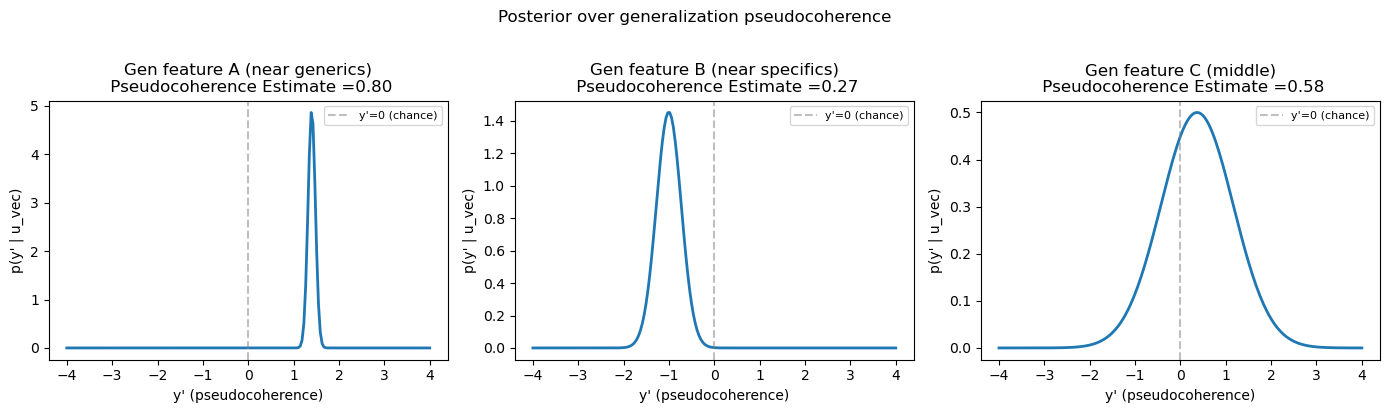

In [7]:
from scipy.special import expit

y_grid = np.linspace(-4, 4, 200)
dy = y_grid[1] - y_grid[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

p_generic = []  # P(z'=1 | u_vec) for each gen feature

for ax, x_prime, label in zip(axes, x_gen, gen_labels):
    log_liks = np.array([
        log_likelihood(
            y_prime=y_p,
            y_vec=y_vec,
            u_vec=u_vec,
            x_prime=x_prime,
            x_vec=x_vec,
            mu_0=mu_0,
            length_scale=length_scale,
            output_scale=output_scale,
            beta=beta,
        )
        for y_p in y_grid
    ])

    log_posterior = log_liks - logsumexp(log_liks)
    posterior = np.exp(log_posterior)
    posterior /= posterior.sum() * dy  # normalize as density

    # E[sigmoid(y')] under posterior = P(z'=1 | u_vec)
    p_z1 = np.sum(expit(y_grid) * posterior) * dy
    p_generic.append(p_z1)

    ax.plot(y_grid, posterior, lw=2)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5, label="y'=0 (chance)")
    ax.set_title(f"Gen feature {label}\n Pseudocoherence Estimate ={p_z1:.2f}")
    ax.set_xlabel("y' (pseudocoherence)")
    ax.set_ylabel("p(y' | u_vec)")
    ax.legend(fontsize=8)

plt.suptitle("Posterior over generalization pseudocoherence", y=1.02)
plt.tight_layout()
plt.show()

## Visualize the 2D embedding space

Show where training and generalization features sit, colored by utterance type.

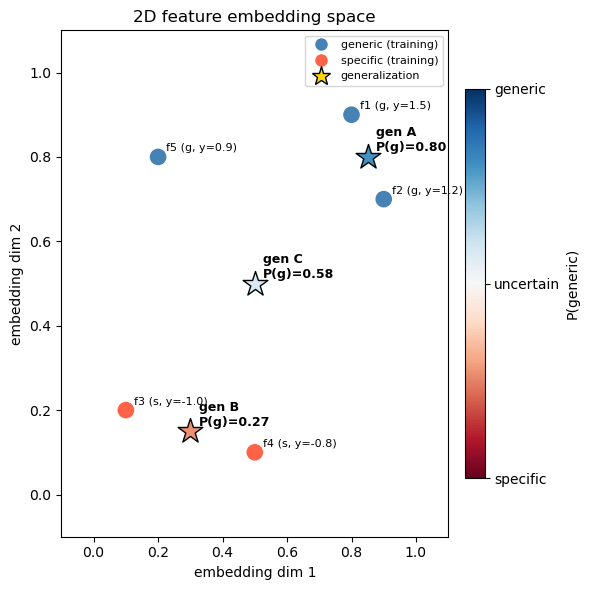

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

# Training features colored by utterance type
colors = ["steelblue" if u == "generic" else "tomato" for u in u_vec]
ax.scatter(x_vec[:, 0], x_vec[:, 1], c=colors, s=120, zorder=3)

for i, (x, y_val, u) in enumerate(zip(x_vec, y_vec, u_vec)):
    ax.annotate(f"f{i+1} ({u[0]}, y={y_val:.1f})", xy=(x[0], x[1]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)

# Generalization features: color stars by P(z'=1) — blue=generic, red=specific
cmap = plt.cm.RdBu
for xp, lbl, p_z1 in zip(x_gen, ["A", "B", "C"], p_generic):
    star_color = cmap(p_z1)  # 0=red (specific), 1=blue (generic)
    ax.scatter(*xp, marker="*", s=350, color=star_color, edgecolors="black", zorder=4)
    ax.annotate(f"gen {lbl}\nP(g)={p_z1:.2f}", xy=(xp[0], xp[1]),
                xytext=(6, 4), textcoords="offset points", fontsize=9, fontweight="bold")

# Colorbar for generalization predictions
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("P(generic)")
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["specific", "uncertain", "generic"])

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='generic (training)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=10, label='specific (training)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=14, label='generalization'),
]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel("embedding dim 1")
ax.set_ylabel("embedding dim 2")
ax.set_title("2D feature embedding space")
plt.tight_layout()
plt.show()